In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    PredictionErrorDisplay,
    root_mean_squared_error, 
    r2_score,
)

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import learning_curve, LearningCurveDisplay
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder, 
    OrdinalEncoder, 
    PowerTransformer, 
    StandardScaler
)

import sys
import os

sys.path.append(os.path.abspath(".."))
from src.config import DADOS_CATEGORIZADOS, DADOS_TRATADOS

from src.utils import dataframe_coeficientes

from src.graficos import plot_coefs, plot_residuos

sns.set_theme(palette="bright")

RANDOM_STATE = 42

In [2]:
df = pd.read_parquet(DADOS_TRATADOS)

df.head()

,idade,sexo,imc,pressao_media,colesterol_total,ldl,hdl,colesterol_hdl,triglicerides,glicose,target
0,59,2,32.099998,101.0,157,93.199997,38.0,4.0,4.8598,87,151
1,48,1,21.600000,87.0,183,103.199997,70.0,3.0,3.8918,69,75
2,72,2,30.500000,93.0,156,93.599998,41.0,4.0,4.6728,85,141
3,24,1,25.299999,84.0,198,131.399994,40.0,5.0,4.8903,89,206
4,50,1,23.000000,101.0,192,125.400002,52.0,4.0,4.2905,80,135


In [3]:
df["sexo"] = df["sexo"].astype("category")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   idade             442 non-null    int8    
 1   sexo              442 non-null    category
 2   imc               442 non-null    float32 
 3   pressao_media     442 non-null    float32 
 4   colesterol_total  442 non-null    int16   
 5   ldl               442 non-null    float32 
 6   hdl               442 non-null    float32 
 7   colesterol_hdl    442 non-null    float32 
 8   triglicerides     442 non-null    float32 
 9   glicose           442 non-null    int8    
 10  target            442 non-null    int16   
dtypes: category(1), float32(6), int16(2), int8(2)
memory usage: 13.6 KB


Colunas para PowerTransformer

- imc
- ldl 
- hdl 
- colesterol_total

Colanas para inteiro 

- colesterol_hdl

Colunas para StandardScaler

- todas as demais

In [4]:
df["colesterol_hdl"] = df["colesterol_hdl"].round().astype("int")

df["colesterol_hdl"].value_counts()

colesterol_hdl
3    141
4    126
5     84
6     41
2     30
7     14
8      5
9      1
Name: count, dtype: int64

<Axes: xlabel='colesterol_hdl'>

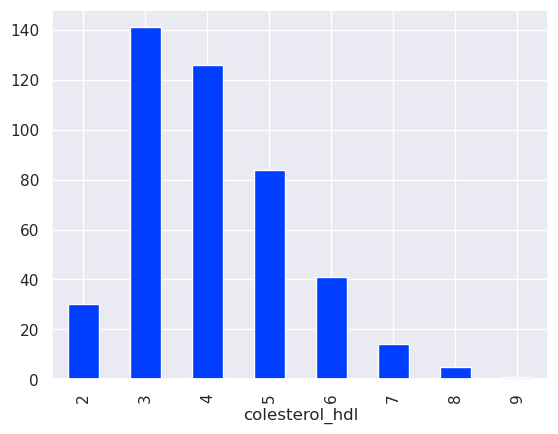

In [5]:
df["colesterol_hdl"].value_counts().sort_index().plot(kind="bar")

In [6]:
df["colesterol_hdl_cat"] = pd.cut(
    df["colesterol_hdl"],
    bins=[2, 4, 6, 10],
    labels=["2-3", "4-5", "6+"],
    right=False,

)

df["colesterol_hdl_cat"].value_counts().sort_index()

colesterol_hdl_cat
2-3    171
4-5    210
6+      61
Name: count, dtype: int64

<Axes: xlabel='colesterol_hdl_cat'>

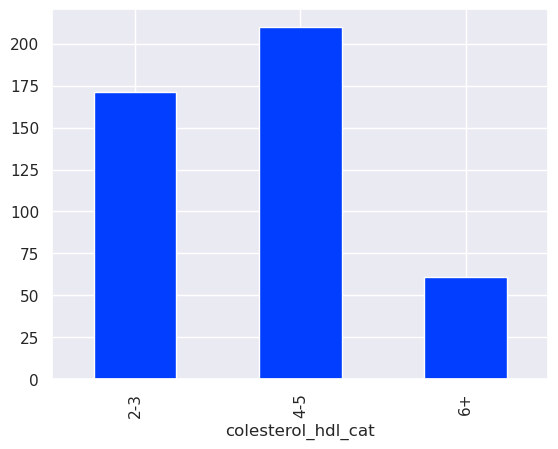

In [7]:
df["colesterol_hdl_cat"].value_counts().sort_index().plot(kind="bar")

In [8]:
df = df.drop(columns=["colesterol_hdl"])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   idade               442 non-null    int8    
 1   sexo                442 non-null    category
 2   imc                 442 non-null    float32 
 3   pressao_media       442 non-null    float32 
 4   colesterol_total    442 non-null    int16   
 5   ldl                 442 non-null    float32 
 6   hdl                 442 non-null    float32 
 7   triglicerides       442 non-null    float32 
 8   glicose             442 non-null    int8    
 9   target              442 non-null    int16   
 10  colesterol_hdl_cat  442 non-null    category
dtypes: category(2), float32(5), int16(2), int8(2)
memory usage: 12.4 KB


In [10]:
df.to_parquet(DADOS_CATEGORIZADOS, index=False)

In [11]:
colunas_power_transform = ["imc", "ldl", "hdl", "colesterol_total"]

colunas_target = ["target"]

coluna_ordinal_encoder = ["colesterol_hdl_cat"]

coluna_one_hot_encoder = ["sexo"]

colunas_standard_scaler = [
    coluna for coluna in df.columns if coluna not in colunas_power_transform + colunas_target + coluna_ordinal_encoder + coluna_one_hot_encoder
]

colunas_standard_scaler

['idade', 'pressao_media', 'triglicerides', 'glicose']

In [13]:
categorias_ordinal_enconder = [
    ["2-3", "4-5", "6+"],
]

In [20]:
X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [25]:
preprocessamento = ColumnTransformer(
    [
        ("power_transform", PowerTransformer(method="box-cox"), colunas_power_transform),
        ("stand_scaler", StandardScaler(), colunas_standard_scaler),
        ("ordenal_encoder", OrdinalEncoder(categories=categorias_ordinal_enconder), coluna_ordinal_encoder),
        ("one_hot_encoder", OneHotEncoder(drop="if_binary"), coluna_one_hot_encoder),
    ]
)

In [27]:
pipeline = Pipeline([
    ("preprocessor", preprocessamento),
    ("reg", LinearRegression())
])

pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('power_transform',
                                                  PowerTransformer(method='box-cox'),
                                                  ['imc', 'ldl', 'hdl',
                                                   'colesterol_total']),
                                                 ('stand_scaler',
                                                  StandardScaler(),
                                                  ['idade', 'pressao_media',
                                                   'triglicerides',
                                                   'glicose']),
                                                 ('ordenal_encoder',
                                                  OrdinalEncoder(categories=[['2-3',
                                                                              '4-5',
                                                                              '6+']]),
                                                  ['colesterol_hdl_cat']),
                                                 ('one_hot_encoder',
                                                  OneHotEncoder(drop='if_binary'),
                                                  ['sexo'])])),
                ('reg', LinearRegression())])

In [28]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('power_transform',
                                                  PowerTransformer(method='box-cox'),
                                                  ['imc', 'ldl', 'hdl',
                                                   'colesterol_total']),
                                                 ('stand_scaler',
                                                  StandardScaler(),
                                                  ['idade', 'pressao_media',
                                                   'triglicerides',
                                                   'glicose']),
                                                 ('ordenal_encoder',
                                                  OrdinalEncoder(categories=[['2-3',
                                                                              '4-5',
                                                                              '6+']]),
                                                  ['colesterol_hdl_cat']),
                                                 ('one_hot_encoder',
                                                  OneHotEncoder(drop='if_binary'),
                                                  ['sexo'])])),
                ('reg', LinearRegression())])

In [30]:
pipeline["reg"].coef_

array([ 24.60290162,  16.78308034,  -0.13707953, -33.23833463,
         0.90944597,  16.86897382,  31.42601038,   3.20214478,
        13.19326488, -24.6891182 ])

In [32]:
pipeline["reg"].intercept_

155.40505733203744

In [39]:
pipeline["preprocessor"].feature_names_in_

array(['idade', 'sexo', 'imc', 'pressao_media', 'colesterol_total', 'ldl',
       'hdl', 'triglicerides', 'glicose', 'colesterol_hdl_cat'],
      dtype=object)

In [40]:
pipeline["preprocessor"].get_feature_names_out()

array(['power_transform__imc', 'power_transform__ldl',
       'power_transform__hdl', 'power_transform__colesterol_total',
       'stand_scaler__idade', 'stand_scaler__pressao_media',
       'stand_scaler__triglicerides', 'stand_scaler__glicose',
       'ordenal_encoder__colesterol_hdl_cat', 'one_hot_encoder__sexo_2'],
      dtype=object)

In [43]:
coefs = dataframe_coeficientes(
    pipeline["reg"].coef_,
    pipeline["preprocessor"].get_feature_names_out()
)

coefs

,coeficiente
power_transform__colesterol_total,-33.238335
one_hot_encoder__sexo_2,-24.689118
power_transform__hdl,-0.137080
stand_scaler__idade,0.909446
stand_scaler__glicose,3.202145
ordenal_encoder__colesterol_hdl_cat,13.193265
power_transform__ldl,16.783080
stand_scaler__pressao_media,16.868974
power_transform__imc,24.602902
stand_scaler__triglicerides,31.426010


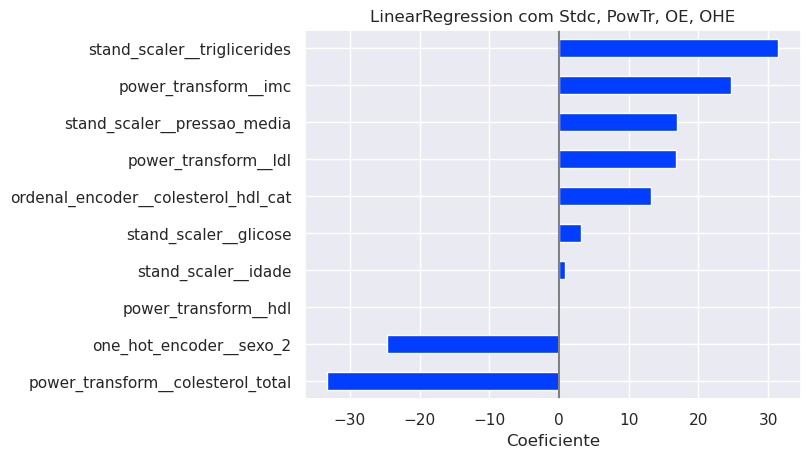

In [47]:
plot_coefs(coefs, "LinearRegression com Stdc, PowTr, OE, OHE")